In [ ]:
from sklearn.model_selection import train_test_split
from matplotlib import pyplot as plt
import tensorflow as tf
from tensorflow import keras
from keras.models import Sequential
from keras.layers import Dense, Flatten, Dropout, Conv2D, MaxPooling2D, BatchNormalization
from google.colab import drive
drive.mount('/content/drive')

In [30]:
print(tf.config.list_physical_devices("GPU"))

[]


In [20]:
#generators
train_ds  = keras.utils.image_dataset_from_directory(
    directory = r"C:\Users\HP\Desktop\handwritten recognization\handwritten-english-characters-and-digits\combined_folder\train",
    labels="inferred",
    label_mode="int",
    batch_size=32,
    image_size=(128, 128),
    
    shuffle=True,
    seed=42,
    
)

validation_ds =  keras.utils.image_dataset_from_directory(
    directory = r"C:\Users\HP\Desktop\handwritten recognization\handwritten-english-characters-and-digits\combined_folder\test",
    labels="inferred",
    label_mode="int",
    batch_size=32,
    image_size=(128, 128),
    
    shuffle=False,
    
    
)

Found 2728 files belonging to 62 classes.
Found 682 files belonging to 62 classes.


In [21]:
#normalize 
def process(image, label):
    image = tf.cast(image/255., tf.float32)
    return image, label

In [22]:
train_ds = train_ds.map(process)
validation_ds = validation_ds.map(process)

In [23]:
import os
import random
import numpy as np 

SEED = 42

os.environ["PYTHONHASHSEED"] = str(SEED)

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

tf.config.experimental.enable_op_determinism()

In [24]:
images, labels = next(iter(train_ds))
images.shape, labels.shape

(TensorShape([32, 128, 128, 3]), TensorShape([32]))

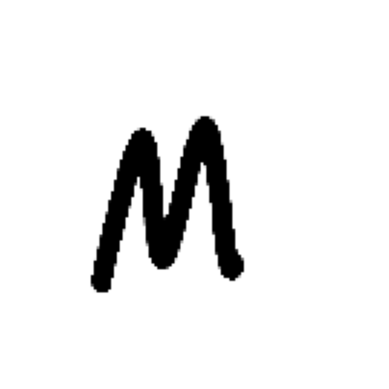

In [26]:
plt.imshow(images[2].numpy())
plt.axis('off')
plt.show()

In [31]:
# model 1 without max pooling and batch normalization and dropout
model1 = Sequential([
    Conv2D(32, kernel_size = (3,3), activation = "relu", input_shape = (128, 128, 3), padding = "valid"),
    Conv2D(64, kernel_size=(3, 3), activation='relu',  padding='valid'),
    Conv2D(128, kernel_size=(3, 3), activation='relu',  padding='valid'),
    Conv2D(256, kernel_size=(3, 3), activation='relu',  padding='valid'),


    Flatten(),
    Dense(256, activation='relu'),
    Dense(128, activation='relu'),
    Dense(62, activation='softmax')
])

model1.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model1.summary()

c:\Users\HP\Desktop\handwritten recognization\venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 124, 124, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 122, 122, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 120, 120, 256)  │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 3686400)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │   943,718,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 62)             │         7,998 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 944,147,966 (3.52 GB)

 Trainable params: 944,147,966 (3.52 GB)

 Non-trainable params: 0 (0.00 B)

In [29]:
history1 = model1.fit(train_ds, validation_data=validation_ds, epochs=10)

Epoch 1/10


c:\Users\HP\Desktop\handwritten recognization\venv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


InvalidArgumentError: Graph execution error:

Detected at node compile_loss/sparse_categorical_crossentropy/SparseSoftmaxCrossEntropyWithLogits/GatherV2 defined at (most recent call last):
  File "<frozen runpy>", line 198, in _run_module_as_main

  File "<frozen runpy>", line 88, in _run_code

  File "c:\Users\HP\Desktop\handwritten recognization\venv\Lib\site-packages\ipykernel_launcher.py", line 18, in <module>

  File "c:\Users\HP\Desktop\handwritten recognization\venv\Lib\site-packages\traitlets\config\application.py", line 1080, in launch_instance

  File "c:\Users\HP\Desktop\handwritten recognization\venv\Lib\site-packages\ipykernel\kernelapp.py", line 807, in start

  File "c:\Users\HP\Desktop\handwritten recognization\venv\Lib\site-packages\tornado\platform\asyncio.py", line 211, in start

  File "C:\Users\HP\AppData\Local\Programs\Python\Python313\Lib\asyncio\base_events.py", line 677, in run_forever

  File "C:\Users\HP\AppData\Local\Programs\Python\Python313\Lib\asyncio\bas